In [1]:
!pip install pandas numpy matplotlib scikit-learn

In [2]:
import warnings
warnings.filterwarnings("ignore")

Dataset Shape: (569, 30)

Decision Tree Accuracy: 0.9474

Random Forest Accuracy: 0.9649

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



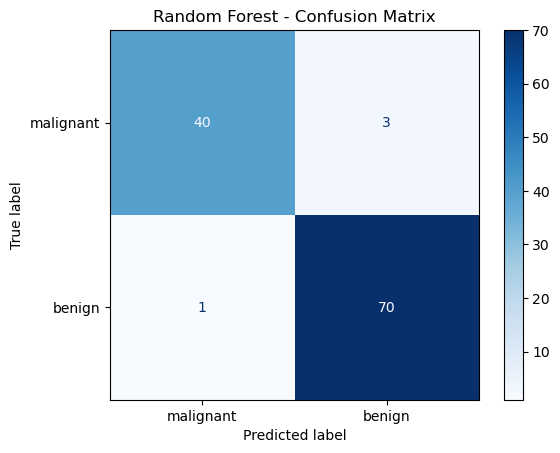

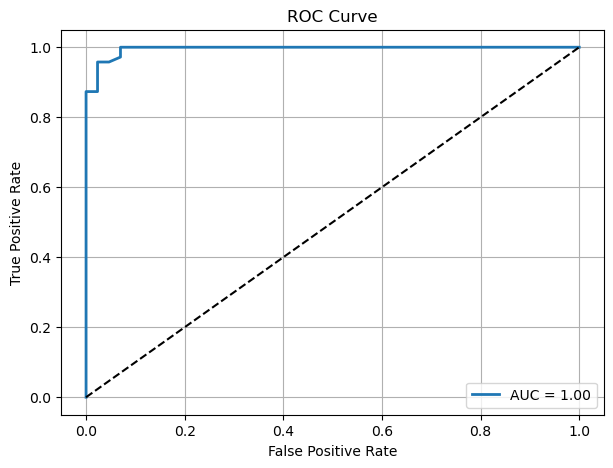


Top 10 Important Features

                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


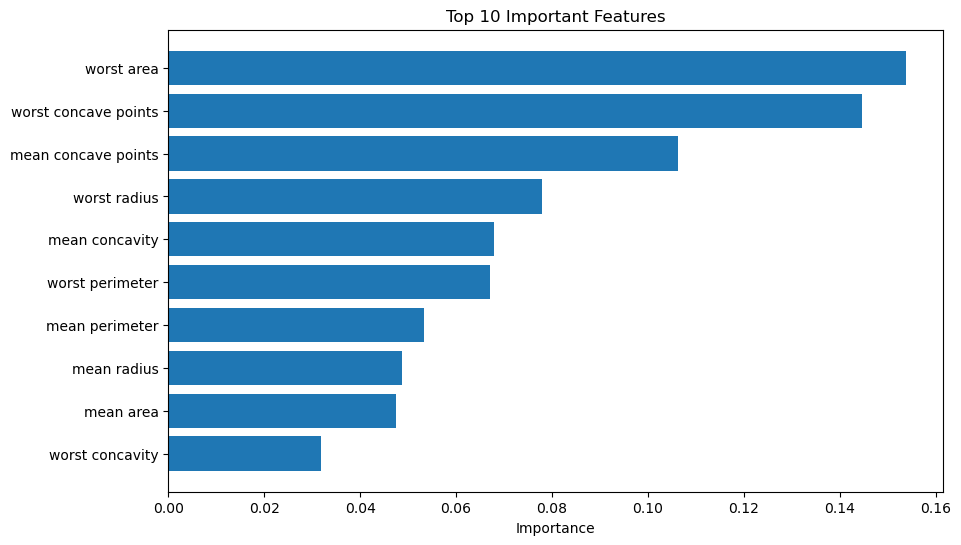


Project Completed Successfully
Decision Tree Accuracy : 94.74 %
Random Forest Accuracy : 96.49 %


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    classification_report
)
# Load Dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("=" * 60)
print("Dataset Shape:", X.shape)
print("=" * 60)


# Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Decision Tree Model

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("\nDecision Tree Accuracy:", round(dt_accuracy, 4))

# Random Forest Model


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("\nRandom Forest Accuracy:", round(rf_accuracy, 4))

# Classification Report


print("\nClassification Report\n")

print(classification_report(y_test, rf_pred))
# Confusion Matrix

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(cmap="Blues")

plt.title("Random Forest - Confusion Matrix")

plt.show()
# ROC Curve

rf_probability = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probability
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features\n")

print(importance.head(10))

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()
# Final Output

print("\n" + "=" * 60)
print("Project Completed Successfully")
print("=" * 60)

print("Decision Tree Accuracy :", round(dt_accuracy * 100, 2), "%")
print("Random Forest Accuracy :", round(rf_accuracy * 100, 2), "%")